# 1. Import Library

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 2. Memuat Dataset

In [75]:
df = pd.read_csv('./data/bank_transactions_data_edited.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   str    
 1   AccountID                2516 non-null   str    
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   str    
 4   TransactionType          2507 non-null   str    
 5   Location                 2507 non-null   str    
 6   DeviceID                 2507 non-null   str    
 7   IP Address               2517 non-null   str    
 8   MerchantID               2514 non-null   str    
 9   Channel                  2510 non-null   str    
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   str    
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance           2510 non-n

In [77]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [78]:
# List kolom yang ingin dibuang sesuai permintaan sebelumnya
kolom_dibuang = [
    'TransactionID', 'AccountID', 'Location', 'DeviceID', 
    'IP Address', 'MerchantID', 'TransactionDate', 'PreviousTransactionDate', 'LoginAttempts'
]
# 1. Membuang kolom yang tidak digunakan
df_clean = df.drop(columns=kolom_dibuang, errors='ignore')
df_clean.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,AccountBalance
0,14.09,Debit,ATM,70.0,Doctor,81.0,5112.21
1,376.24,Debit,ATM,68.0,Doctor,141.0,13758.91
2,126.29,Debit,Online,19.0,Student,56.0,1122.35
3,184.50,Debit,Online,26.0,Student,25.0,8569.06
4,13.45,Credit,Online,NaN,Student,198.0,7429.40


In [79]:
# Cek missing values
print("\nMissing values per fitur:")
print(df_clean.isnull().sum())


Missing values per fitur:
TransactionAmount      26
TransactionType        30
Channel                27
CustomerAge            18
CustomerOccupation     23
TransactionDuration    26
AccountBalance         27
dtype: int64


# 3. Exploratory Data Analysis (EDA)

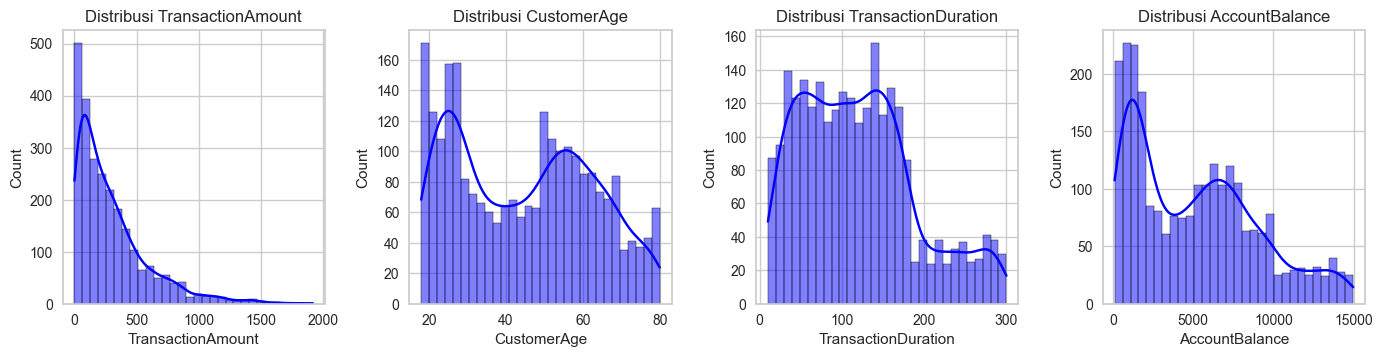

In [80]:
# Distribusi fitur numerik
num_features = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df_clean[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

C:\Users\Rafly\AppData\Local\Temp\ipykernel_11516\581725380.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in df_clean.select_dtypes(include=['object', 'category']).columns


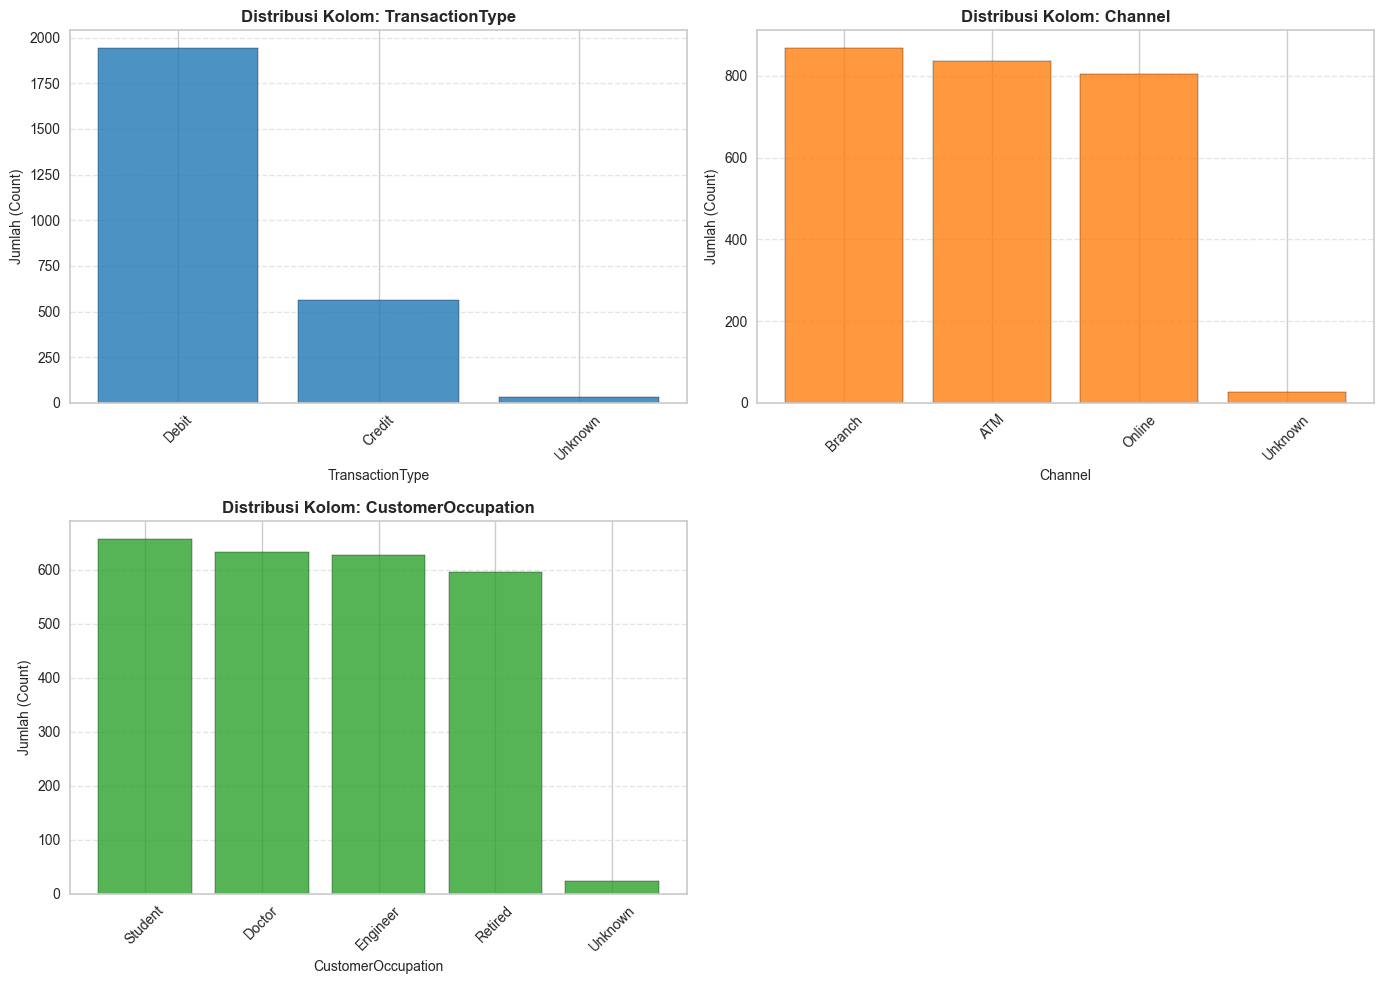

In [81]:

# 1. Cari kolom kategorikal dengan jumlah nilai unik <= 15
categorical_cols = [
    col for col in df_clean.select_dtypes(include=['object', 'category']).columns
    if df_clean[col].nunique() <= 15
]
# 2. Menentukan layout grid subplot (2 kolom per baris)
n_cols = 2
n_rows = (len(categorical_cols) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()  # Mengubah matriks axes menjadi 1D agar mudah diakses dalam loop
# 3. Looping untuk menggambar grafik di setiap subplot
for i, col in enumerate(categorical_cols):
    # Hitung jumlah frekuensi kategori
    counts = df_clean[col].fillna('Unknown').value_counts()
    
    # Buat diagram batang
    axes[i].bar(
        counts.index, 
        counts.values, 
        color=plt.cm.tab10(i % 10), # Menggunakan warna berbeda untuk tiap grafik
        edgecolor='black', 
        alpha=0.8
    )
    
    # Memberi judul dan label
    axes[i].set_title(f'Distribusi Kolom: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Jumlah (Count)', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45) # Miringkan teks label agar terbaca
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
# 4. Hapus subplot kosong jika jumlah kolom kategorikal ganjil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

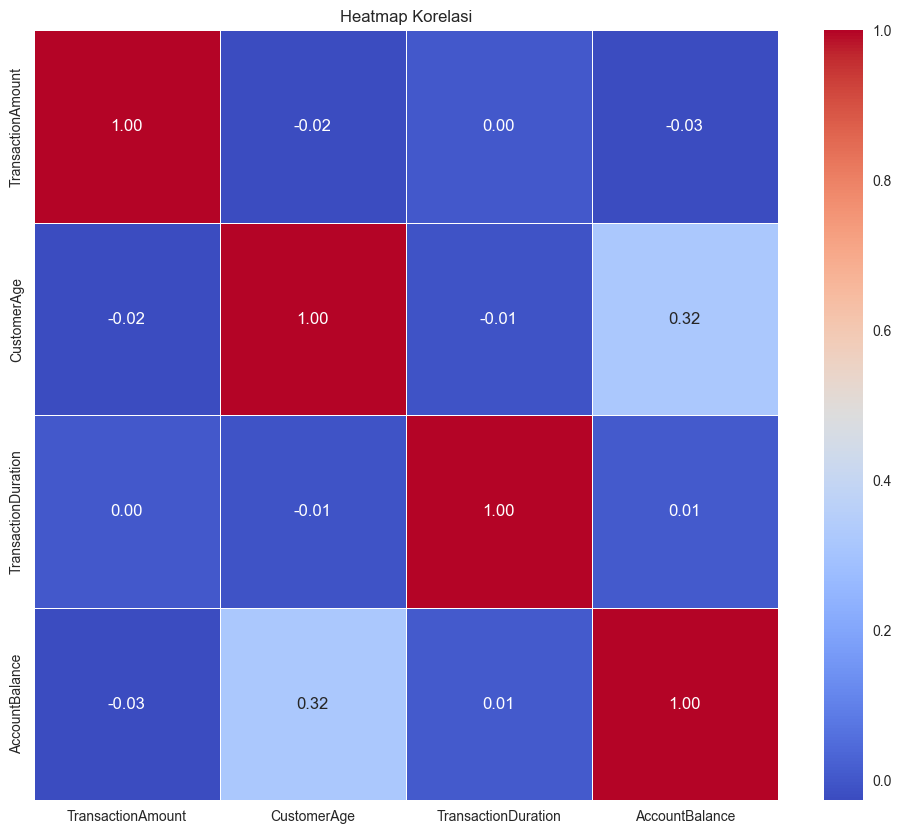

In [82]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

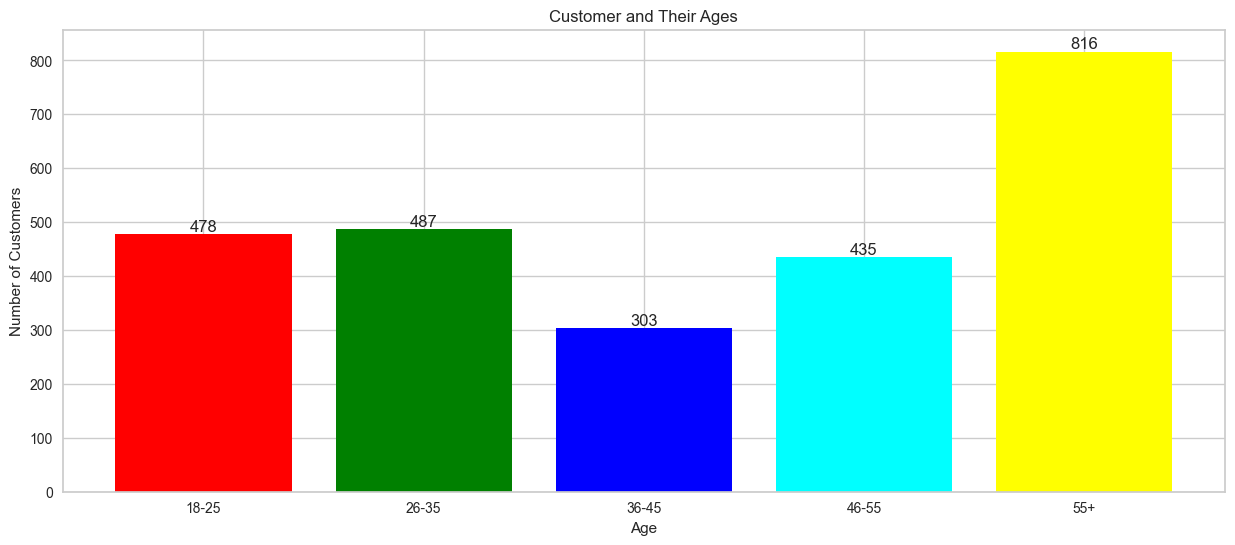

In [83]:
# Mengelompokkan usia pelanggan ke dalam kategori dan menghitung jumlah pelanggan di setiap kategori
age18_25 = df_clean.CustomerAge[(df_clean.CustomerAge >= 18) & (df_clean.CustomerAge <= 25)]
age26_35 = df_clean.CustomerAge[(df_clean.CustomerAge >= 26) & (df_clean.CustomerAge <= 35)]
age36_45 = df_clean.CustomerAge[(df_clean.CustomerAge >= 36) & (df_clean.CustomerAge <= 45)]
age46_55 = df_clean.CustomerAge[(df_clean.CustomerAge >= 46) & (df_clean.CustomerAge <= 55)]
age55above = df_clean.CustomerAge[df.CustomerAge >= 56]

# Menyusun data untuk plotting
x = ["18-25", "26-35", "36-45", "46-55", "55+"]
y = [len(age18_25.values), len(age26_35.values), len(age36_45.values), len(age46_55.values), len(age55above.values)]
 
# Membuat bar chart untuk distribusi usia pelanggan
plt.figure(figsize=(15, 6))
plt.bar(x, y, color=['red', 'green', 'blue', 'cyan', 'yellow'])
plt.title("Customer and Their Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
 
# Menambahkan label jumlah pelanggan di atas setiap bar
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')
 
plt.show()

# 4. Data Preprocessing

In [84]:
# Menghapus baris jika ada salah satu kolom yang bernilai NaN
df_clean = df_clean.dropna()

In [85]:
# Cek missing values
print("\nMissing values per fitur:")
print(df_clean.isnull().sum())


Missing values per fitur:
TransactionAmount      0
TransactionType        0
Channel                0
CustomerAge            0
CustomerOccupation     0
TransactionDuration    0
AccountBalance         0
dtype: int64


In [86]:
df_clean.describe()

,TransactionAmount,CustomerAge,TransactionDuration,AccountBalance
count,2363.000000,2363.000000,2363.000000,2363.000000
mean,298.391189,44.611088,119.639441,5082.054879
std,292.519457,17.886598,70.572915,3901.739560
min,0.260000,18.000000,10.000000,101.250000
25%,81.760000,27.000000,63.000000,1484.075000
50%,212.970000,45.000000,112.000000,4658.890000
75%,414.630000,59.000000,162.000000,7652.485000
max,1919.110000,80.000000,300.000000,14977.990000


In [96]:
numeric_features = df_clean.select_dtypes(include=['number']).columns

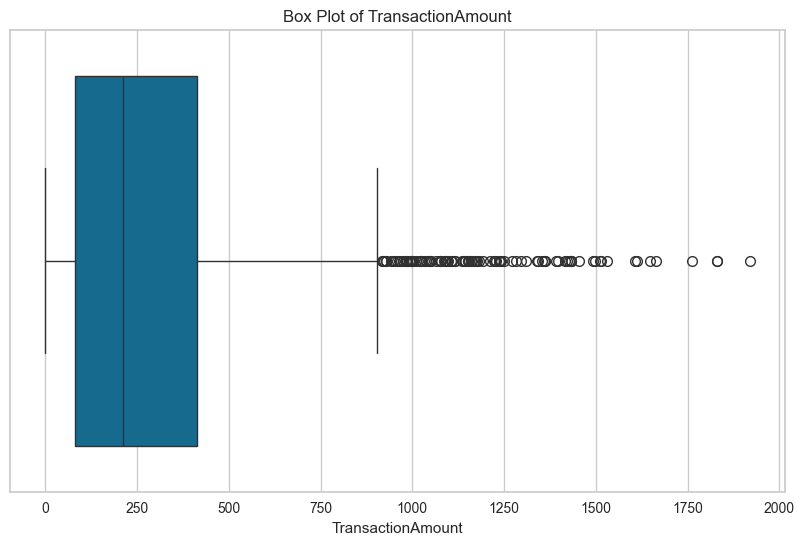

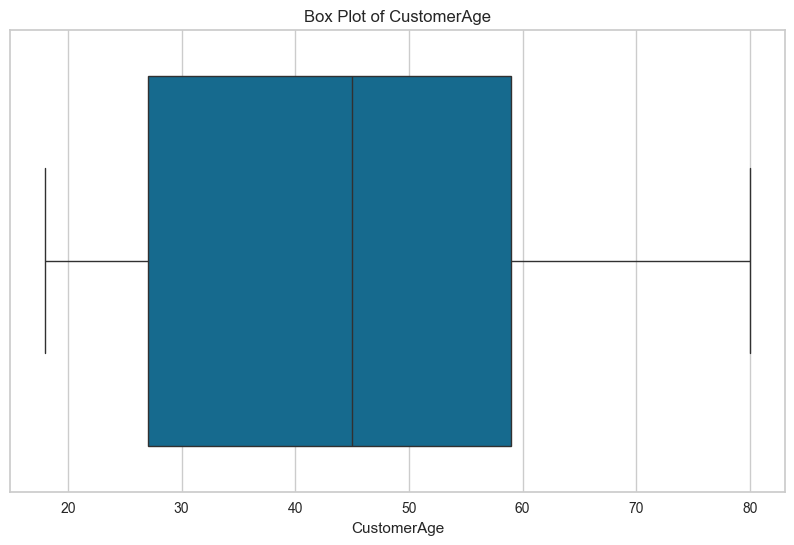

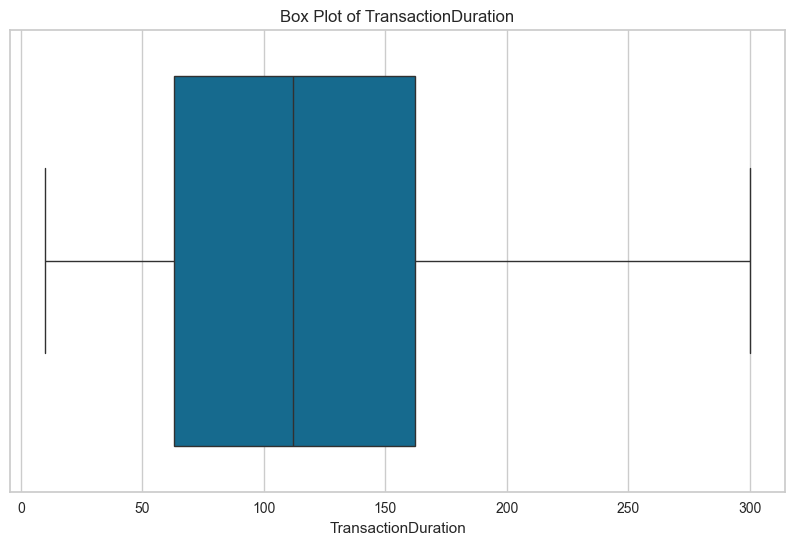

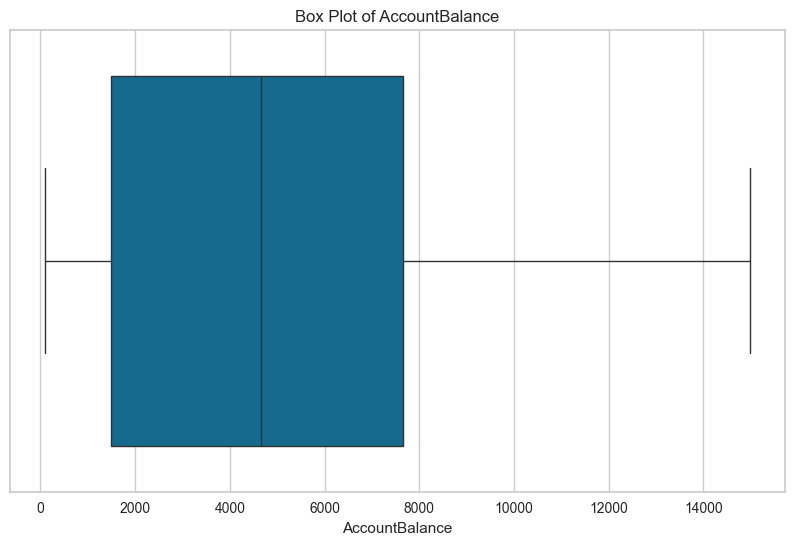

In [97]:
for feature in numeric_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_clean[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()